In [1]:
import numpy as np
from math import pi
from spatialmath import *

import ipywidgets as widgets
import matplotlib.pyplot as plt


In [2]:
%matplotlib widget
%matplotlib widget

In [3]:
R1 = SO3.Rx(pi/4)

In [4]:
type(R1)

spatialmath.pose3d.SO3

In [5]:
R1

   1         0         0         
   0         0.7071   -0.7071    
   0         0.7071    0.7071    


In [6]:
R1 * R1

   1         0         0         
   0         0        -1         
   0         1         0         


In [7]:
SO3.Rx(pi/2)

   1         0         0         
   0         0        -1         
   0         1         0         


In [8]:
R1**2

   1         0         0         
   0         0        -1         
   0         1         0         


In [9]:
SO3.Rx(45,'deg')

   1         0         0         
   0         0.7071   -0.7071    
   0         0.7071    0.7071    


In [10]:
#fig = plt.figure()# create a new figure
#SE3().plot(frame='0',dims=[-1.5,1.5],color='black')
#R1.plot(frame='1')

In [11]:
R2 = SO3.RPY([10, 20, 30], unit= 'deg')
R2

   0.8138   -0.441     0.3785    
   0.4698    0.8826    0.01803   
  -0.342     0.1632    0.9254    


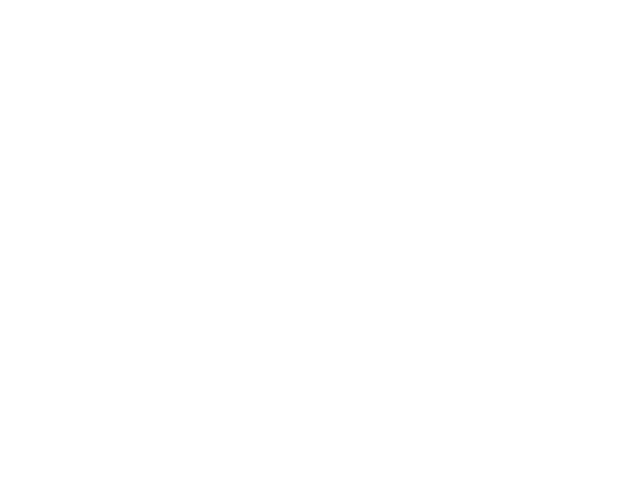

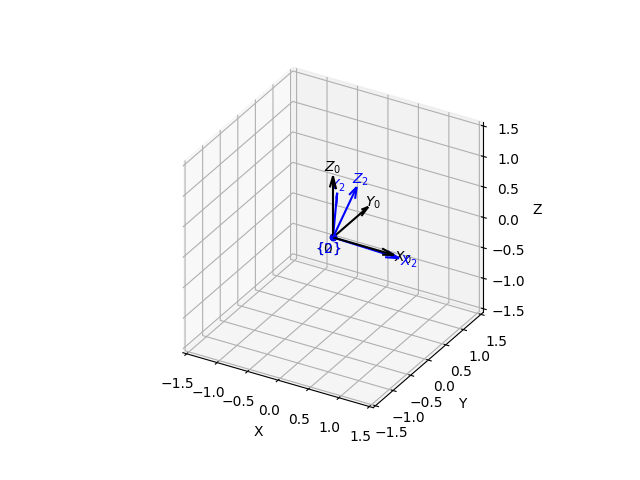

In [12]:
plt.figure() # create a new figure
SE3().plot(frame='0',dims=[-1.5, 1.5],color='black')
R2.plot(frame='2')

In [13]:
R2.rpy()

array([0.17453293, 0.34906585, 0.52359878])

In [14]:
SO3()

   1         0         0         
   0         1         0         
   0         0         1         


In [15]:
#from orientation and approach vectors
SO3.OA(o=[0,0,-1], a=[1,0,0])

   0         0         1         
  -1         0         0         
   0        -1         0         


In [16]:
#redo our earlier example using SO3.Rx()
SO3.AngVec(pi/4,[1,0,0])

   1         0         0         
   0         0.7071   -0.7071    
   0         0.7071    0.7071    


In [17]:
#or
SO3.Exp([pi/4,0,0])

   1         0         0         
   0         0.7071   -0.7071    
   0         0.7071    0.7071    


In [18]:
#or a more complex example
SO3.AngVec(30,[1,2,3],unit='deg')

   0.8756   -0.3818    0.296     
   0.42      0.9043   -0.07621   
  -0.2386    0.191     0.9522    


In [19]:
# the object has a number of properties such as the columns which are often written as R= [n,o,a] where n,o,a are 
# 3-vectors

R1.n

array([1., 0., 0.])

In [20]:
#or its inverse (in this case transpose)
R1.inv()

   1         0         0         
   0         0.7071    0.7071    
   0        -0.7071    0.7071    


In [21]:
#the shape of the underlying matrix
R1.shape

(3, 3)

In [22]:
#and the order
R1.N
#indicating it operates in 3D space

3

In [23]:
#checking various properties of the object
[R1.isSE,R1.isSO,R1.isrot(),R1.ishom(),R1.isrot2(),R1.ishom2()]
# last 4 provide compatibility with the MATLAB toolbox

[False, True, True, False, False, False]

In [24]:
q1 = Quaternion([1,2,3,4])
q1

 1.0000 <  2.0000,  3.0000,  4.0000 >


In [25]:
q1.s
#we extract the scalar part

1

In [26]:
#and the vector part
q1.v

array([2, 3, 4])

In [27]:
#nor represent as numpy array
q1.vec

array([1, 2, 3, 4])

In [28]:
#quaternion conjugate
q1.conj()

 1.0000 < -2.0000, -3.0000, -4.0000 >


In [29]:
#and norm, which is the magnitude of the equivalent 4 vector.
q1.norm()

5.477225575051661

In [30]:
#second quaternion
q2 = Quaternion([5,6,7,8])
q2

 5.0000 <  6.0000,  7.0000,  8.0000 >


In [31]:
# we can add
q1 + q2

 6.0000 <  8.0000,  10.0000,  12.0000 >


In [32]:
#substract
q1 - q2

-4.0000 < -4.0000, -4.0000, -4.0000 >


In [33]:
#and multiply
q1 * q2

-60.0000 <  12.0000,  30.0000,  24.0000 >


In [34]:
# which follows the special rules fo Hamiltonian multiplication
# Multiplication can also be performed as the linear algebraic product of one quaternion converted
# to 4x4 matrix
q1.matrix

array([[ 1., -2., -3., -4.],
       [ 2.,  1., -4.,  3.],
       [ 3.,  4.,  1., -2.],
       [ 4., -3.,  2.,  1.]])

In [35]:
#and the other as a 4-vector
q1.matrix @ q2.vec

array([-60.,  12.,  30.,  24.])

In [36]:
# the product of a quaternion and its conjugate is a scalar equalt to the square of its norm
q1* q1.conj()

 30.0000 <  0.0000,  0.0000,  0.0000 >


In [37]:
# conversely, a quaternion with a zero scalar part is called a pure quaternion.
Quaternion.Pure([1,2,3])

 0.0000 <  1.0000,  2.0000,  3.0000 >


In [38]:
#Unit quaternions
#A quaternion with a unit norm is called a unit quaternion. it is a group and its elements represent 
# rotations in 3D space. it is SO3 matrix except for a double mapping. 
# A quaternion and its elemnt-wise negation represent same rotation.

q1 = UnitQuaternion.Rx(30, 'deg')
q1

 0.9659 <<  0.2588,  0.0000,  0.0000 >>


In [39]:
# the convention is that unit quaternions are denoted using deouble angle brackets. 
#The norm, as advertised is indeed 1    

q1.norm()

1.0

In [40]:
# We created another unit quaternion

q2 = UnitQuaternion.Ry(-40 , 'deg')
q2

 0.9397 <<  0.0000, -0.3420,  0.0000 >>


In [41]:
#the rotations can be composed by quaternion multiplication

q3 = q1 * q2
q3

 0.9077 <<  0.2432, -0.3304, -0.0885 >>


In [42]:
# we can convert a quaternion to a rotation matrix
q3.R

array([[ 7.66044443e-01, -2.77555756e-17, -6.42787610e-01],
       [-3.21393805e-01,  8.66025404e-01, -3.83022222e-01],
       [ 5.56670399e-01,  5.00000000e-01,  6.63413948e-01]])

In [43]:
# which yields the same answer as if we'd done it uisng SO(3) rotation matrices

SO3.Rx(30, 'deg') * SO3.Ry(-40,'deg') 

   0.766     0        -0.6428    
  -0.3214    0.866    -0.383     
   0.5567    0.5       0.6634    


In [44]:
#The advantages of unit quaternions are that
#they are compact, just 4 numbers instead of 9
#multiplication involves fewer operations and is therefore faster

#numerical errors build up when we multiply rotation matrices together many times,
#  and they lose the structure (the columns are no longer unit length or orthogonal). 
# Correcting this, the process of normalization is expensive. For unit quaternions errors will also
#  compound, but normalization is simply a matter of dividing through by the norm

# Unit quaternions have an inverse

q2.inv()

 0.9397 << -0.0000,  0.3420, -0.0000 >>


In [45]:
q1 * q2.inv()

 0.9077 <<  0.2432,  0.3304,  0.0885 >>


In [46]:
#or 
q1/q2

 0.9077 <<  0.2432,  0.3304,  0.0885 >>


In [47]:
# we can convert any unit quaternion to an SO3 obj

q1.SO3()

   1         0         0         
   0         0.866    -0.5       
   0         0.5       0.866     


In [48]:
#and conversely any SO3 obj to a unit quaternion

UnitQuaternion(SO3.Rx(30,'deg'))

 0.9659 <<  0.2588,  0.0000,  0.0000 >>


In [49]:


#A unit quaternion is not a minimal representation. Since we know the magnitude is 1,
#  then with any 3 elements we can compute the fourth upto a sign ambiguity.
q1.vec3


array([0.25881905, 0.        , 0.        ])

In [50]:
a = UnitQuaternion.qvmul(q1.vec3,q2.vec3)
a

array([ 0.24321035, -0.33036609, -0.08852133])

In [51]:
#from which we can recreate the unit quaternion

UnitQuaternion.Vec3(a)


 0.9077 <<  0.2432, -0.3304, -0.0885 >>


In [52]:
#In robotics we also need to describe the position of objects and we can do this with a homogeneous transformation matrix – a 4x4 matrix – which belong to the group which is a subset of all 4x4 real matrices.

#We can create such a matrix, for a translation of 1 in the x-direction, 2 in the y-direction and 3 in the z-direction by

T1 = SE3(1, 2, 3)
T1

   1         0         0         1         
   0         1         0         2         
   0         0         1         3         
   0         0         0         1         


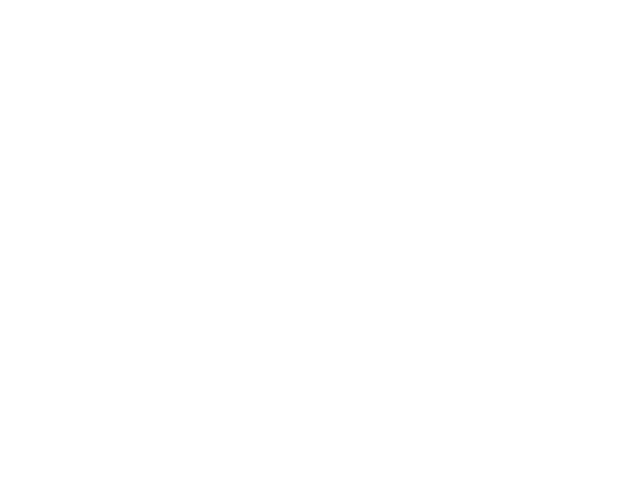

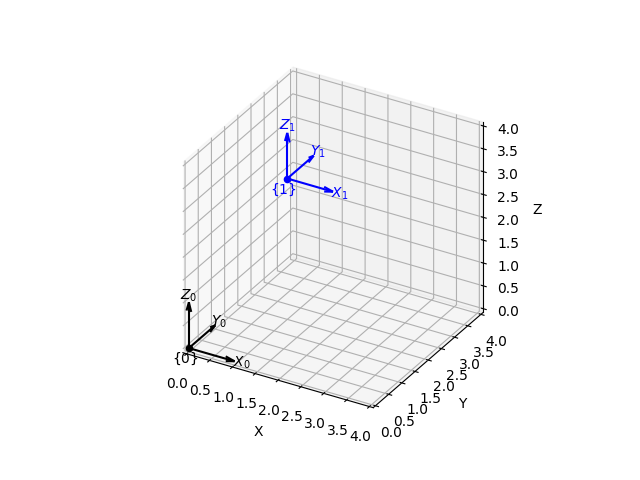

In [53]:
#We can visualize this

plt.figure() # create a new figure
SE3().plot(frame='0', dims=[0,4], color='black')
T1.plot(frame='1')

In [54]:
#

#We can define another translation
T12 = SE3(2, -1, -2)

In [55]:


#and compose it with T1

T2 = T1 * T12
T2.plot(frame= '2', color='red')


In [56]:
# Representing pose

T1 = SE3(1,2,3) * SE3.Rx(30, 'deg') 
T1

   1         0         0         1         
   0         0.866    -0.5       2         
   0         0.5       0.866     3         
   0         0         0         1         


Is a composition of two motions: a pure translation and then a pure rotation. We can see the rotation matrix, computed above, in the top-left corner and the translation components in the right-most column. In the earlier example Out[24] was simply a null-rotation which is represented by the identity matrix.

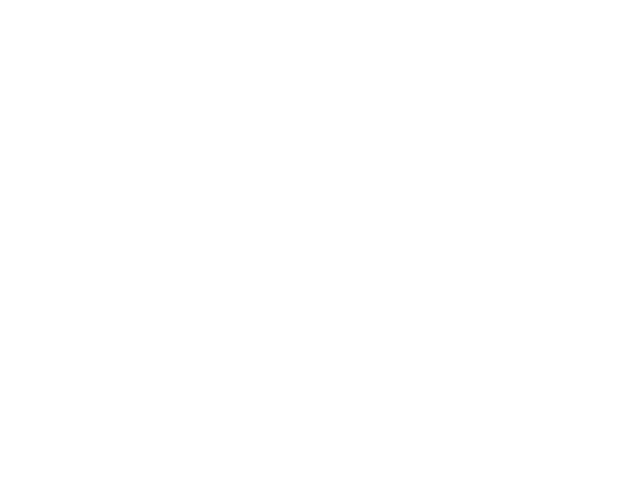

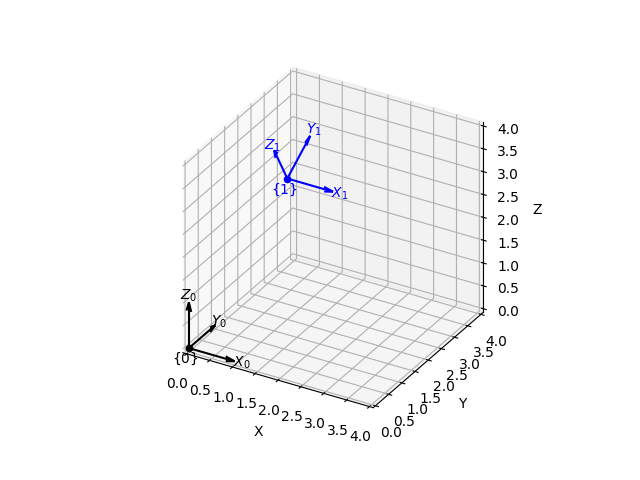

In [57]:
# the frame now looks like this

plt.figure() #create a new figure
SE3().plot(frame='0',dims=[0,4],color= 'black')
T1.plot(frame= '1')

## Properties
The object has a number of properties, such as the columns which are often written as [n,o,a]

In [58]:
T1.o

array([0.       , 0.8660254, 0.5      ])

In [59]:
#or its inverse (computed in ana efficient manner based on the structure of the matrix)
T1.inv()

   1         0         0        -1         
   0         0.866     0.5      -3.232     
   0        -0.5       0.866    -1.598     
   0         0         0         1         


In [60]:
#We can extract the rotation matrix as a numpy array
T1.R

array([[ 1.       ,  0.       ,  0.       ],
       [ 0.       ,  0.8660254, -0.5      ],
       [ 0.       ,  0.5      ,  0.8660254]])

In [61]:
#or the translation vector, as a numpy array
T1.t

array([1., 2., 3.])

In [62]:
# the shape fo the underlying SE(3) matrix is

T1.shape

(4, 4)

In [63]:
#and the order
T1.N

3

indicating it operates in 3D space.

## Predicates
We can check various properties

In [64]:
[T1.isSE, T1.isSO, T1.isrot(), T1.ishom(), T1.isrot2(), T1.ishom2()]

[True, False, False, True, False, False]


## A couple of important points:

When we compose motions they must be of the same type. An SE3 object can represent pure transation, pure rotation or both. If we wish to compose a translation with a rotation, the rotation must be an SE3 object - a rotation plus zero translation.

SUperset


## Transforming points
Imagine now a set of points defining the vertices of a cube

In [65]:
P = np.array([[-1, 1, 1, -1, -1, 1, 1, -1], [-1, -1, 1, 1, -1, -1, 1, 1], [-1, -1, -1, -1, 1, 1, 1, 1]])
P

array([[-1,  1,  1, -1, -1,  1,  1, -1],
       [-1, -1,  1,  1, -1, -1,  1,  1],
       [-1, -1, -1, -1,  1,  1,  1,  1]])

defined with respect to a body reference frame $^{A}P_{i}$. Given a transformation $^{0}T_{A}$ from the world frame to the body frame, we determine the coordinates of the points in the world frame by $^{0}P_{i} =^{0}T_{A} ^{A}P_{i} $ which we can perform in a single operation

In [66]:
Q = T1 * P

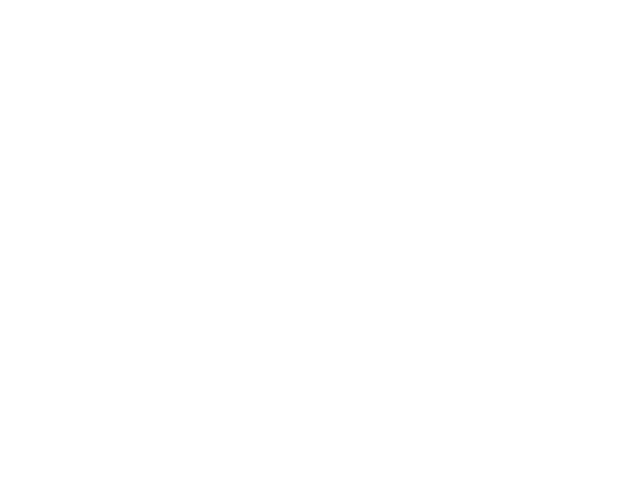

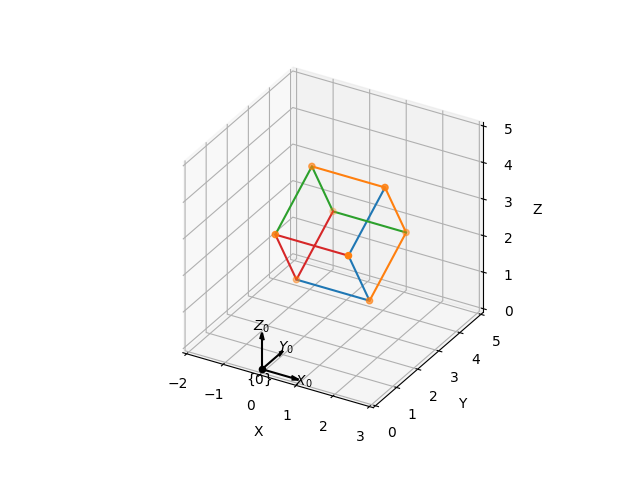

In [67]:
#now plotting

fig = plt.figure()
SE3().plot(frame='0', dims=[-2,3,0,5,0,5],color='black')
ax = plt.gca()
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.scatter(xs=Q[0], ys=Q[1], zs=Q[2], s=20) # draw vertices

# draw lines joining the vertices
lines= [[0,1,5,6],[1,2,6,7],[2,3,7,4],[3,0,4,5]]
for line in lines:
    ax.plot([Q[0,i] for i in line],[Q[1,i] for i in line],[Q[2,i] for i in line])

This is often used in SLAM and bundle adjustment algorithms since it is compact and better behaved than using roll-pitch-yaw or Euler angles.

## Twists


A twist is an alternative way to represent a 3D pose, but it is more succinct, comprising just 6 values. In constrast an SE(3) matrix has 16 values with a considerable amount of redundancy, but it does offer consider computational convenience.

In [68]:
# Twists are the logarithm of an SE(3) matrix

T = SE3.Rand()
T

   0.8259    0.5624    0.0396   -0.2141    
  -0.5531    0.7947    0.25     -0.5273    
   0.1091   -0.2284    0.9674    0.8099    
   0         0         0         1         


In [69]:
T.log()

array([[ 0.        ,  0.59953087, -0.03735858, -0.02436942],
       [-0.59953087,  0.        ,  0.25708104, -0.67534754],
       [ 0.03735858, -0.25708104,  0.        ,  0.73774881],
       [ 0.        ,  0.        ,  0.        ,  0.        ]])

In [70]:
# How do we know this is really the logarithm? Well we can exponentiate it!
lg = T.log()
SE3.Exp(lg)

   0.8259    0.5624    0.0396   -0.2141    
  -0.5531    0.7947    0.25     -0.5273    
   0.1091   -0.2284    0.9674    0.8099    
   0         0         0         1         


and we have reconstituted our original matrix.

The logarithm is a matrix with a very particular structure, it has a zero diagonal and bottom row, and the top-left 3x3 matrix is skew symmetric. This matrix has only 6 unique elements: three from the last column, and three from the skew symmetric matrix, and we can request the log method to give us just these

In [71]:
T.log(twist= True)

array([-0.02436942, -0.67534754,  0.73774881, -0.25708104, -0.03735858,
       -0.59953087])



This 6-vector is a twist, a concise way to represent the translational and rotational components of a pose. Twists are represented by their own class


In [72]:
tw = Twist3(T)
tw 

(-0.024369 -0.67535 0.73775; -0.25708 -0.037359 -0.59953)

Just like the other pose objects, Twist3 objects can have multiple values.

In [73]:
# Twists can be composed

T = SE3(1,2,3) * SE3.Rx(0.3)
tw = Twist3(T)
tw

(1 2.435 2.6775; 0.3 0 0)

In [74]:
# Now we can compose the twists

tw2 = tw* tw
tw2

(2 4.87 5.3549; 0.6 0 0)



and the result is just the same as if we had composed the transforms


In [75]:
Twist3(T* T)

(2 4.87 5.3549; 0.6 0 0)

Twists have great utility for robot arm kinematics, to compute the forward kinematics and Jacobians. Twist objects have a number of methods.

In [76]:
# The adjoint is a 6x6 matrix that relates velocities

tw.Ad()

array([[ 1.        ,  0.        ,  0.        ,  0.        , -2.27496905,
         2.7972336 ],
       [ 0.        ,  0.95533649, -0.29552021,  3.        , -0.29552021,
        -0.95533649],
       [ 0.        ,  0.29552021,  0.95533649, -2.        ,  0.95533649,
        -0.29552021],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.95533649,
        -0.29552021],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.29552021,
         0.95533649]])



and the SE3 object also has this method.

The logarithm of the adjoint is given by


In [77]:
tw.ad()

array([[ 0.        , -0.        ,  0.        ,  0.        , -2.67746618,
         2.43497745],
       [ 0.        ,  0.        , -0.3       ,  2.67746618,  0.        ,
        -1.        ],
       [-0.        ,  0.3       ,  0.        , -2.43497745,  1.        ,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -0.        ,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -0.3       ],
       [ 0.        ,  0.        ,  0.        , -0.        ,  0.3       ,
         0.        ]])



The name twist comes from considering the rigid-body motion as a rotation and a translation along a unique line of action. It rotates as it moves along the line following a screw like motion, hence its other name as a screw. The line in 3D space is described in Plücker coordinates by


In [79]:
tw.line

<bound method Twist3.line of Twist3([1, 2.435, 2.6775, 0.3, 0, 0])>

In [81]:
# the pitch of the screw is

tw.pitch

0.3

In [83]:
tw.pole

array([ 0.        , -2.67746618,  2.43497745])

## Working in 2D

Things are actually much simpler in 2D. There's only one possible rotation which is around an axis perpendicular to the plane (where the z-axis would have been if it were in 3D).

Rotations in 2D can be represented by rotation matrices – 2x2 orthonormal matrices – which belong to the group SO(2). Just as for the 3D case these matrices have special properties, each column (and row) is a unit vector, and they are all orthogonal, the inverse of this matrix is equal to its transpose, and its determinant is +1.


In [85]:
# we can create such a matrix, a rotation of pi/4 radians by

R = SO2(pi/4)
R

   0.7071   -0.7071    
   0.7071    0.7071    


In [86]:
# or in degrees

SO2(45, unit= 'deg')

   0.7071   -0.7071    
   0.7071    0.7071    


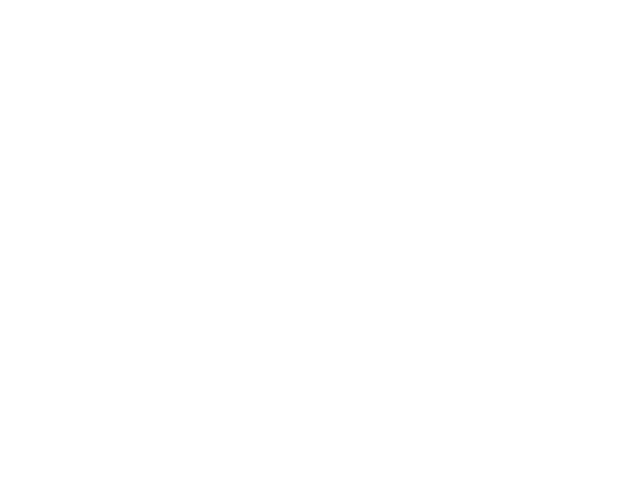

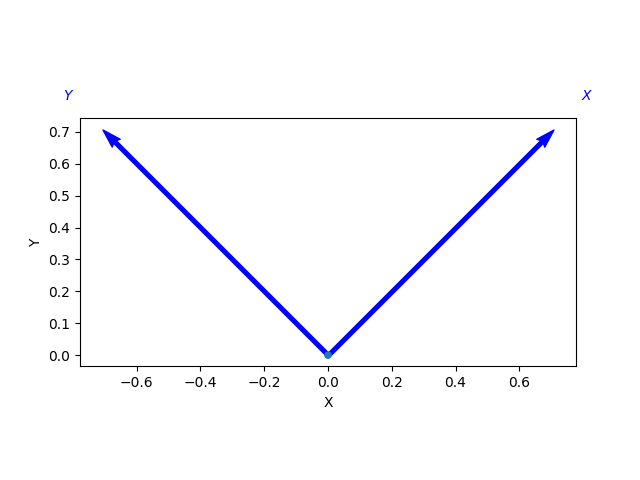

In [87]:
# and we can plot this on the 2D plane

plt.figure() #create a new figure
R.plot()



Once again, it's useful to describe the position of things and we do this this with a homogeneous transformation matrix – a 3x3 matrix – which belong to the group SE(2).


In [88]:
T = SE2(1,2)
T

   1         0         1         
   0         1         2         
   0         0         1         


which has a similar structure to the 3D case. The rotation matrix is in the top-left corner and the translation components are in the right-most column.

In [89]:
# We can also call the function with the element in a list

T = SE2([1,2])

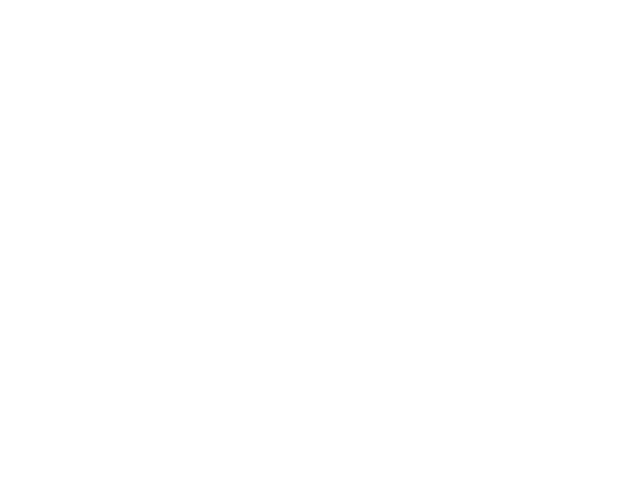

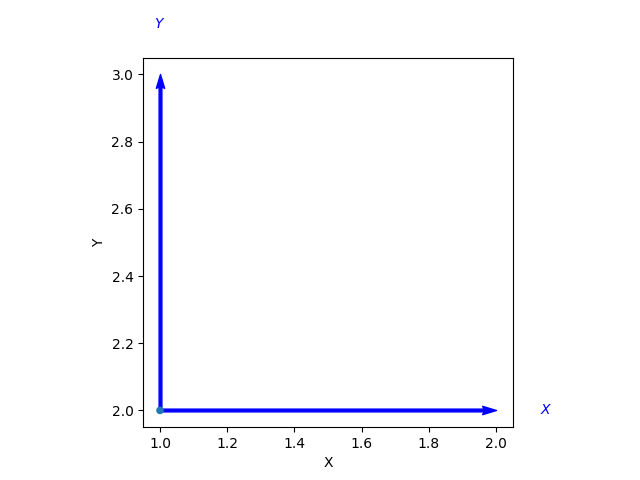

In [90]:
plt.figure() # create new fig
T.plot()

In [91]:
T2 = SE2(45,unit='deg')
T2

   0.7071   -0.7071    0         
   0.7071    0.7071    0         
   0         0         1         


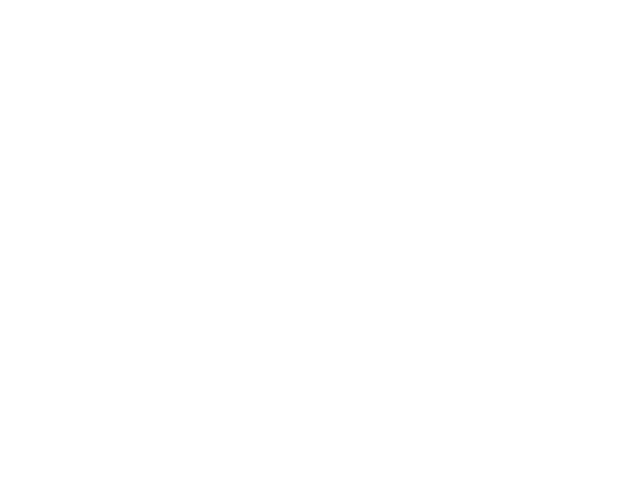

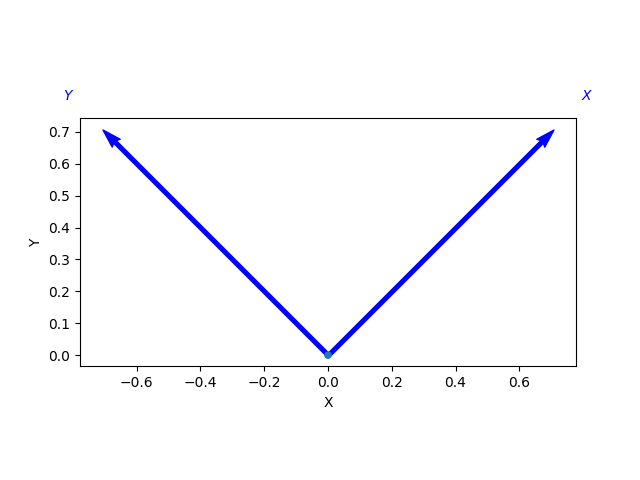

In [92]:
plt.figure()#another one
T2.plot()

In [93]:
#The inplace versions of operators are also supported, for example

X = T

X /= T2
X


   0.7071    0.7071    1         
  -0.7071    0.7071    2         
   0         0         1         


## Operators

### Group operators

For the 3D case, the classes we have introduced mimic the behavior the mathematical groups SO(3) and SE(3) which contain matrices of particular structure. They are subsets respectively of the sets of all possible real 3x3 and 4x4 matrices.

The only operations on two elements of the group that also belongs to the group are composition (represented by the * operator) and inversion.

In [95]:
T1 = SE3(1,2,3) * SE3.Rx(30,'deg')
[type(T1),type(T1.inv()),type(T1*T1)]

[spatialmath.pose3d.SE3, spatialmath.pose3d.SE3, spatialmath.pose3d.SE3]



If we know the pose of frame {2} and a rigid body motion from frame {1} to frame {2}


In [96]:
T2 = SE3(4,5,6) * SE3.Ry(-40,'deg')
T12 = SE3(0,-2,-1) * SE3.Rz(70,'deg')

In [97]:
# then 0T1 * 1T2 = 0T2 then 0T1= 0T1*(0T2)^-1 which we write as

T1* T2.inv()

   0.766     0         0.6428   -5.921     
   0.3214    0.866    -0.383    -1.318     
  -0.5567    0.5       0.6634   -1.254     
   0         0         0         1         


In [98]:
# or more concisely as 

T1/T2

   0.766     0         0.6428   -5.921     
   0.3214    0.866    -0.383    -1.318     
  -0.5567    0.5       0.6634   -1.254     
   0         0         0         1         


In [99]:
# Exponentations is also a group operator since it is simple repeated composition

T1 ** 2

   1         0         0         2         
   0         0.5      -0.866     2.232     
   0         0.866     0.5       6.598     
   0         0         0         1         


## Non- Group operations

Operations such as addition and subtraction are valid for matrices but not for elements of the group, therefore these operations will return a numpy array rather than a group object

In [100]:
SE3() + SE3()

array([[2., 0., 0., 0.],
       [0., 2., 0., 0.],
       [0., 0., 2., 0.],
       [0., 0., 0., 2.]])

In [101]:
#yields an array not an SE3 object. As do other non group operations

2 * SE3()

array([[2., 0., 0., 0.],
       [0., 2., 0., 0.],
       [0., 0., 2., 0.],
       [0., 0., 0., 2.]])

In [102]:
SE3() - 1

array([[ 0., -1., -1., -1.],
       [-1.,  0., -1., -1.],
       [-1., -1.,  0., -1.],
       [-1., -1., -1.,  0.]])



Similar principles apply to quaternions. Unit quaternions are a group and only support composition and inversion. Any other operations will return an ordinary quaternion


In [103]:
UnitQuaternion() * 2

 2.0000 <  0.0000,  0.0000,  0.0000 >


which is indicated by the single angle brackets.

## In-place operators

All of Pythons in-place operators are available as well, whether for group or non-group operations. For example

In [104]:
T = T1
T *= T2
T **= 2

## Multi-valued objects

For many tasks we might want to have a set or sequence of rotations or poses. The obvious solution would be to use a Python list

In [105]:
T = [ SE3.Rx(0), SE3.Rx(0.1), SE3.Rx(0.2), SE3.Rx(0.3), SE3.Rx(0.4)]



but the pose objects in this package can hold multiple values, just like a native Python list can. There are a few ways to do this, most obviously


In [106]:
T = SE3( [ SE3.Rx(0), SE3.Rx(0.1), SE3.Rx(0.2), SE3.Rx(0.3), SE3.Rx(0.4)] )

In [107]:
# which has type of a pose object

type(T)

spatialmath.pose3d.SE3

In [108]:
# but it has length of five

len(T)

5



that is, it contains five values. We can see these when we display the object's value


In [109]:
T

0:
   1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         
1:
   1         0         0         0         
   0         0.995    -0.09983   0         
   0         0.09983   0.995     0         
   0         0         0         1         
2:
   1         0         0         0         
   0         0.9801   -0.1987    0         
   0         0.1987    0.9801    0         
   0         0         0         1         
3:
   1         0         0         0         
   0         0.9553   -0.2955    0         
   0         0.2955    0.9553    0         
   0         0         0         1         
4:
   1         0         0         0         
   0         0.9211   -0.3894    0         
   0         0.3894    0.9211    0         
   0         0         0         1         




We can index into the object (slice it) just as we would a Python list


In [111]:
T[3]

   1         0         0         0         
   0         0.9553   -0.2955    0         
   0         0.2955    0.9553    0         
   0         0         0         1         




or from the second element to the last in steps of two


In [112]:
T[1:-1:2]

0:
   1         0         0         0         
   0         0.995    -0.09983   0         
   0         0.09983   0.995     0         
   0         0         0         1         
1:
   1         0         0         0         
   0         0.9553   -0.2955    0         
   0         0.2955    0.9553    0         
   0         0         0         1         




We could another value to the end


In [113]:
T.append(SE3.Rx(0.5))
len(T)

6

The SE3 class, like all the classes in this package, inherits from the UserList class giving it all the methods of a Python list like append, extend, del etc. We can also use them as iterables in for loops and in list comprehensions.

You can create an object of a particular type with no elements using this constructor

In [114]:
T = SE3.Empty()
len(T)

0



which is the equivalent of setting a variable to [].



We could write the above example more succinctly


In [116]:
T = SE3.Rx(np.linspace(0,0.5,5))
len(T)

5

In [117]:
T[3]

   1         0         0         0         
   0         0.9305   -0.3663    0         
   0         0.3663    0.9305    0         
   0         0         0         1         


In [118]:
# consider another rotation

T2 = SE3.Ry(40,'deg')

In [119]:
# if we write

A = T * T2

len(A)

5



we obtain a new list where each element of A is T[i] * T2. Similarly


In [120]:
B = T2 * T

len(B)

5

which has produced a new list where each element of B is T2 * T[i].

In [121]:
# similarly
C = T *T
len(C)


5

yields a new list where each element of C is the T[i] * T[i].

We can apply such a sequence to a coordinate vectors as we did earlier

In [122]:
P = T * [0,1,0]

P 

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [1.        , 0.99219767, 0.96891242, 0.93050762, 0.87758256],
       [0.        , 0.12467473, 0.24740396, 0.36627253, 0.47942554]])

where each element of T has transformed the coordinate vector (0, 1, 0), the results being consecutive columns of the resulting numpy array.

This is equivalent to writing

In [123]:
np.column_stack([x * [0,1,0] for x in T])

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [1.        , 0.99219767, 0.96891242, 0.93050762, 0.87758256],
       [0.        , 0.12467473, 0.24740396, 0.36627253, 0.47942554]])

## C++ line programming model

Lists are useful, but we might like to use a programming model where we allocate an array of pose objects and reference them or assign to them. We can do that to!

In [124]:
T = SE3.Alloc(5) # create a vector of SE3 values

for i, theta in enumerate(np.linspace(0,1,len(T))):
    T[i] = SE3.Rz(theta)
T

0:
   1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         
1:
   0.9689   -0.2474    0         0         
   0.2474    0.9689    0         0         
   0         0         1         0         
   0         0         0         1         
2:
   0.8776   -0.4794    0         0         
   0.4794    0.8776    0         0         
   0         0         1         0         
   0         0         0         1         
3:
   0.7317   -0.6816    0         0         
   0.6816    0.7317    0         0         
   0         0         1         0         
   0         0         0         1         
4:
   0.5403   -0.8415    0         0         
   0.8415    0.5403    0         0         
   0         0         1         0         
   0         0         0         1         




Alloc initializes every element to the identity value. This technique works for all pose objects.
